In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
#LOAD DATA
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
#df.dtypes
#df.isnull().sum()
#df.describe()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


on voit clairement le déséquilibre de classes :

* No → 5174 clients (environ 74%)
* Yes → 1869 clients (environ 26%)

💡 **Interprétation**
* La majorité des clients restent (No)
* Une minorité quitte (Yes)
Cela signifie que si on fait juste une prédiction naïve “No”, on aurait ~74% d’accuracy… mais le modèle ne serait pas utile.

⚠️ **Donc, pour ce dataset :**

* On utilisera des métriques adaptées : F1-score, ROC-AUC, Precision/Recall
* On pourra appliquer :
class_weight='balanced' dans les modèles (Logistic Regression, Random Forest…)
ou techniques comme SMOTE pour équilibrer la classe minoritaire


In [3]:
# Conversion en float, les erreurs deviennent NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Supprimer les lignes avec NaN dans TotalCharges
df = df[df['TotalCharges'].notnull()]
#Ce code nettoie le dataset en supprimant les lignes où TotalCharges n’a pas de valeur numérique.

In [4]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


# 🔹 Comment StandardScaler fonctionne ?

**Formule :**

$$
X_{\text{scaled}} = \frac{X - \mu}{\sigma}
$$

- $X$ = valeur originale  
- $\mu$ = moyenne de la colonne  
- $\sigma$ = écart-type de la colonne  

**Résultat :**

- Moyenne ≈ 0 (ou très proche de 0)  
- Écart-type ≈ 1  

---



In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [6]:
df[num_cols].dtypes

df[num_cols].isnull().sum()

,0
tenure,0
MonthlyCharges,0
TotalCharges,0


In [7]:
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.032000e+03,7.032000e+03,7.032000e+03
mean,-1.126643e-16,6.062651e-17,-1.119064e-16
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01
50%,-1.394171e-01,1.845440e-01,-3.908151e-01
75%,9.199259e-01,8.331482e-01,6.668271e-01
max,1.612573e+00,1.793381e+00,2.824261e+00


## 3️⃣ Interprétation des résultats

| Colonne           | mean  | std  | min     | max     |
|------------------|-------|------|---------|---------|
| tenure            | ≈ 0   | ≈ 1  | -1.28   | 1.61    |
| MonthlyCharges    | ≈ 0   | ≈ 1  | -1.55   | 1.79    |
| TotalCharges      | ≈ 0   | ≈ 1  | -0.99   | 2.82    |

- **Moyenne ≈ 0** → toutes les colonnes centrées autour de 0  
- **Écart-type ≈ 1** → les colonnes sont sur la même “taille”  
- **Valeurs négatives et positives** → indiquent si la valeur est **en dessous ou au-dessus de la moyenne**  
  - Exemple : `tenure = -1.28` → client avec ancienneté très inférieure à la moyenne  
  - Exemple : `TotalCharges = 2.82` → client avec total payé beaucoup plus élevé que la moyenne  

✅ C’est exactement ce qu’on veut avant de passer à des modèles sensibles à l’échelle.  

---

💡 **Résumé simple :**

> `StandardScaler` transforme les colonnes numériques pour qu’elles aient **la même échelle** (moyenne = 0, écart-type = 1).  
> Cela aide les modèles ML à **ne pas favoriser les variables avec des valeurs très grandes**.

# 🔹 Préparation des données pour le Machine Learning – Projet Churn

Avant de modéliser, il est important de **préparer correctement toutes les colonnes**.  
On va passer par ces étapes :  
1️⃣ Colonnes numériques → StandardScaler  
2️⃣ Colonnes binaires → conversion 0/1  
3️⃣ Colonnes catégorielles multi-classes → OneHotEncoding  
4️⃣ Colonnes inutiles → suppression  

---

## 1️⃣ Colonnes numériques

Les colonnes numériques sont : `tenure`, `MonthlyCharges`, `TotalCharges`.  
On applique un **StandardScaler** pour centrer les données (moyenne = 0) et mettre l’écart-type = 1.


# 🔹 Colonnes binaires et catégorielles – Préparation pour le ML

Après avoir normalisé les colonnes numériques (`tenure`, `MonthlyCharges`, `TotalCharges`), il est important de **préparer les colonnes catégorielles et binaires**.

---

## 2️⃣ Colonnes binaires

- Ce sont des colonnes avec **2 valeurs uniques** (souvent `Yes`/`No`).  
- Exemple : `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`.  

**Transformation :**  
- `Yes` → 1  
- `No` → 0  


In [8]:
df.dtypes
#Parcourir les colonnes pour voir le nombres de valeurs uniques

for col in df.columns:
  print(col , df[col].nunique() , df[col].unique())

 # nunique() calcule le nombre de valeurs uniques dans la colonne col
 #unique() affiche toutes les valeurs distinctes présentes dans la colonne
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]
drop_cols = ['customerID']

customerID 7032 ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender 2 ['Female' 'Male']
SeniorCitizen 2 [0 1]
Partner 2 ['Yes' 'No']
Dependents 2 ['No' 'Yes']
tenure 72 [-1.28024804  0.06430269 -1.23950408  0.51248626 -0.99504031 -0.42462485
 -0.91355239 -0.18016108  1.2051336  -0.7913205  -0.66908862  1.04215776
  0.6754621  -0.30239297  1.49034133  0.79769399  1.57182925 -0.46536881
 -0.83206446 -0.09867316  0.59397418  1.61257321 -0.62834466 -0.22090504
 -1.11727219  0.55323022 -0.87280842  1.53108529  1.24587756  0.43099834
 -0.70983258  1.12364568 -0.5876007   1.36810945 -0.95429635 -1.19876011
 -0.0579292   0.71620607  1.28662152  0.96066983 -1.03578427  0.39025438
  0.10504665  0.63471814 -0.13941712  1.32736548  0.22727853  1.44959737
 -0.01718524  0.91992587  0.18653457  0.14579061  0.34951041 -1.07652823
 -1.15801615  0.02355872  1.40885341 -0.38388089  1.00141379  1.16438964
 -0.75057654 -0.50611277  0.83843795  0.30876645  1.08290172 

# 🔹 Mapping Binaire pour le Machine Learning

Dans cette étape, nous allons transformer toutes les colonnes **binaires** de notre dataset (Yes/No, Male/Female) en **valeurs numériques 0 et 1**, ce que l'on appelle le **mapping binaire**.

---

## 1️⃣ Qu’est-ce que le mapping binaire ?

- Certaines colonnes contiennent du texte comme `Yes/No` ou `Male/Female`.
- Les modèles de Machine Learning **ne comprennent pas le texte**, ils ont besoin de **nombres**.
- Le mapping binaire consiste à remplacer ces valeurs par des **0 et 1**.

**Exemples :**

| Colonne   | Original | Mapping → |
|-----------|---------|-----------|
| Partner   | Yes     | 1         |
| Partner   | No      | 0         |
| Churn     | Yes     | 1         |
| Churn     | No      | 0         |
| Gender    | Male    | 1         |
| Gender    | Female  | 0         |

---

## 2️⃣ Pourquoi c’est important ?

- Les modèles ML **ne peuvent pas traiter du texte**.
- Les algorithmes comme Logistic Regression, Random Forest ou XGBoost nécessitent que toutes les variables soient **numériques**.
- Les valeurs 0/1 représentent simplement la **présence ou l’absence** d’une caractéristique.

---

## 3️⃣ Comment faire le mapping binaire ?

1. Pour toutes les colonnes binaires Yes/No :

```python
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})
```

2. Pour Gender (Male/Female) :

```python
df['gender'] = df['gender'].map({'Female':0, 'Male':1})
```

- `map()` prend un dictionnaire et remplace les anciennes valeurs par les nouvelles.  
- Après cette étape, toutes les colonnes binaires contiennent uniquement **0 et 1**.

---

## 4️⃣ Que vérifier après le mapping ?

```python
df[binary_cols + ['gender']].head()
```

- Toutes les valeurs doivent être **0 ou 1**.  
- Plus de `Yes/No` ou `Male/Female` dans ces colonnes.

---

## 5️⃣ Prochaine étape après le mapping binaire

1. Appliquer **OneHotEncoding** sur les colonnes catégorielles multi-classes (`Contract`, `PaymentMethod`, etc.).  
2. Supprimer les colonnes inutiles comme `customerID`.

💡 **Astuce** : Cette étape prépare correctement les données pour que le modèle ML fonctionne correctement et évite les erreurs.

In [9]:
# Reload dataset propre
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Nettoyer noms colonnes
df.columns = df.columns.str.strip()

# Colonnes binaires (SANS SeniorCitizen)
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

# Mapping
for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

# Gender
df['gender'] = df['gender'].map({'Female':0,'Male':1})

# Vérification
df[['gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling','Churn']].head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,0,1,0,0,1,0
1,1,0,0,0,1,0,0
2,1,0,0,0,1,1,1
3,1,0,0,0,0,0,0
4,0,0,0,0,1,1,1


# 🔹 Transformation des colonnes catégorielles (OneHotEncoding)

Dans cette étape, nous transformons les colonnes **catégorielles** (texte avec plusieurs valeurs) en **variables numériques** afin de les rendre utilisables par les modèles de Machine Learning.

---

## 1️⃣ Problème

Certaines colonnes contiennent du texte, par exemple :
- `Contract` → Month-to-month, One year, Two year  
- `PaymentMethod` → Electronic check, Mailed check, etc.

👉 Les modèles de Machine Learning **ne comprennent pas le texte**.

---

## 2️⃣ Solution : OneHotEncoding

Nous utilisons la fonction `pd.get_dummies()` pour transformer chaque catégorie en une colonne binaire (0/1).

Exemple :

Avant :
```
Contract = One year
```

Après :
```
Contract_One year = 1  
Contract_Two year = 0
```

---

## 3️⃣ Implémentation

```python
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
```

- `columns=categorical_cols` → colonnes à transformer  
- `drop_first=True` → évite la redondance (multicolinéarité)

---

## 4️⃣ Résultat

- Les colonnes texte sont supprimées  
- De nouvelles colonnes numériques (0/1) sont créées  
- Le dataset devient **100% numérique**

---

## 5️⃣ Importance

Cette étape est essentielle car :
- Elle permet aux modèles ML de traiter les données  
- Elle évite les erreurs liées aux variables catégorielles  
- Elle améliore la performance des modèles  

---

💡 **Conclusion :** OneHotEncoding transforme les variables catégorielles en format exploitable par les algorithmes de Machine Learning.


In [10]:
# OneHotEncoding + sauvegarde
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Supprimer customerID
df = df.drop('customerID', axis=1)

# Vérification
df.head()
#df.shape

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.5,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [11]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [12]:
# Vérifier les valeurs uniques pour les colonnes binaires
for col in binary_cols:
    print(col, df[col].unique())

Partner [1 0]
Dependents [0 1]
PhoneService [0 1]
PaperlessBilling [1 0]
Churn [0 1]


In [13]:
# Vérifier le type de chaque colonne
print(df.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                              object
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [15]:
# Convertir TotalCharges en numérique
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplacer les NaN par la médiane, sans inplace
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Vérification
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head())

float64
0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [16]:
df.dtypes


,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int64




# 📝 Préparation des données pour le Machine Learning

Après avoir transformé toutes les colonnes binaires et catégorielles en format numérique (0/1), nous sommes prêts pour la phase de préparation finale des données pour l’entraînement d’un modèle.



### ✅ Résumé

1. Séparer **X** (features) et **y** (target).
2. Faire un **train/test split**.
3. Standardiser les colonnes numériques.
4. Choisir et entraîner un modèle adapté.
5. Évaluer les performances sur le test set.

---



## 1️⃣ Séparation des features et de la target

* **Target (`y`)** : la variable que l’on souhaite prédire.
  Exemple : `Churn` (0 = client fidèle, 1 = client churn).
* **Features (`X`)** : toutes les autres colonnes qui serviront à prédire la target.
* **Objectif** : isoler ce que le modèle doit apprendre (X) de ce qu’il doit prédire (y).

In [17]:
X = df.drop('Churn', axis =1 )
y = df['Churn']

## 2️⃣ Division du dataset en train et test

* **Train set** : utilisé pour entraîner le modèle.
* **Test set** : utilisé pour évaluer la performance sur des données jamais vues.
* **Stratification** : permet de conserver la même proportion de classes (ex : churn/non-churn) dans train et test.


In [23]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42 , stratify = y)


## 3️⃣ Normalisation / standardisation des colonnes numériques

* Les colonnes continues comme `tenure`, `MonthlyCharges`, `TotalCharges` sont mises à l’échelle.
* **Objectif** : éviter que certaines variables dominent le modèle à cause de leur grandeur.
* Les colonnes binaires et celles issues du OneHotEncoding **n’ont pas besoin d’être mises à l’échelle**.

In [24]:
scaler_1 =StandardScaler()
x_train[['tenure' , 'MonthlyCharges','TotalCharges']] = scaler_1.fit_transform(x_train[['tenure','MonthlyCharges','TotalCharges']])
x_test[['tenure' , 'MonthlyCharges','TotalCharges']] = scaler_1.fit_transform(x_test[['tenure','MonthlyCharges','TotalCharges']])


## 4️⃣ Choix et entraînement du modèle

* Sélectionner un modèle adapté à la **classification binaire**, par exemple :

  * Logistic Regression
  * Random Forest
  * XGBoost / LightGBM
* **Objectif** : apprendre la relation entre les features et la target à partir du train set.

In [25]:
from sklearn.ensemble import RandomForestClassifier

model =RandomForestClassifier(random_state =42)
model.fit(x_train ,y_train)
y_pred = model.predict(x_test)

## 5️⃣  Évaluation d’un modèle de classification binaire avec `classification_report` et `confusion_matrix`




Après avoir entraîné un modèle, on mesure ses performances sur un ensemble test pour vérifier sa capacité à prédire correctement.

* Tester le modèle sur l’ensemble test pour mesurer ses performances.
* Mesures typiques :

  * Accuracy (taux de bonnes prédictions)
  * Precision, Recall, F1-score
  * Matrice de confusion
* **Objectif** : s’assurer que le modèle généralise bien sur des données qu’il n’a jamais vues.  


---

## 1️⃣ Confusion Matrix (Matrice de confusion)

La matrice de confusion est une **représentation 2x2** pour la classification binaire :

|          | Prédit = 0 | Prédit = 1 |
| -------- | ---------- | ---------- |
| Réel = 0 | **TN**     | **FP**     |
| Réel = 1 | **FN**     | **TP**     |

* **TP (True Positive)** : vrai positif, le modèle a prédit 1 et c’était réellement 1
* **TN (True Negative)** : vrai négatif, le modèle a prédit 0 et c’était réellement 0
* **FP (False Positive)** : faux positif, le modèle a prédit 1 mais c’était 0
* **FN (False Negative)** : faux négatif, le modèle a prédit 0 mais c’était 1

**Intérêt :** permet de visualiser **où le modèle se trompe** et de comprendre le type d’erreurs (faux positifs vs faux négatifs).

**Exemple pratique :**

* Dans la prédiction de churn :

  * FP = prédire qu’un client va churn alors qu’il reste → actions inutiles
  * FN = ne pas détecter un client qui va churn → perte réelle

---

## 2️⃣ Classification Report (`classification_report`)

`classification_report` de `sklearn` calcule **plusieurs métriques par classe**, en se basant sur la matrice de confusion :

### Métriques principales :

1. **Precision (Précision)**

$
\text{Precision} = \frac{TP}{TP + FP}
$

* **Interprétation :** parmi les prédictions positives, combien étaient correctes
* **Intérêt :** limiter les fausses alertes (FP)

2. **Recall (Rappel / Sensibilité)**

$
\text{Recall} = \frac{TP}{TP + FN}
$

* **Interprétation :** parmi les vrais positifs, combien le modèle a détecté
* **Intérêt :** limiter les faux négatifs (FN)

3. **F1-score**

$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$

* **Interprétation :** moyenne harmonique entre precision et recall
* **Intérêt :** équilibre les erreurs FP et FN, surtout utile sur des classes déséquilibrées

4. **Support**

* Nombre réel d’échantillons dans chaque classe.

---

## 3️⃣ Accuracy (Exactitude)

$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$

* Proportion totale de prédictions correctes sur toutes les observations.
* Limite : peut être trompeuse si les classes sont déséquilibrées.

---

## 4️⃣ Exemple pratique

* `y_test` = valeurs réelles
* `y_pred` = valeurs prédites par le modèle


* La **confusion matrix** montre TP, TN, FP, FN
* Le **classification_report** donne precision, recall, f1-score, support pour chaque classe

---

## ✅ Résumé

* `confusion_matrix` → visualise les erreurs spécifiques
* `classification_report` → résume performance par métrique pour chaque classe
* Accuracy → vue globale mais limitée si classes déséquilibrées
* Precision → fiabilité des prédictions positives
* Recall → capacité à détecter tous les positifs
* F1 → compromis entre precision et recall









In [26]:
# on mesure  la performance sur l'ensemble test :
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

# Accuracy
acc=accuracy_score(y_test , y_pred)
print("Accuracy:", acc)

#Classification_Report
print(classification_report(y_test ,y_pred))

#Confusion matrix
cm=confusion_matrix(y_test , y_pred)
print(cm)

Accuracy: 0.7828246983676366
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.45      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

[[933 102]
 [204 170]]




---

## 1️⃣ Matrice de confusion

La matrice :

```
[[933 102]
 [204 170]]
```

* **Lignes = classes réelles (0 = non-churn, 1 = churn)**
* **Colonnes = classes prédites (0 = non-churn, 1 = churn)**

| Réel \ Prédit | 0 (non-churn) | 1 (churn) |
| ------------- | ------------- | --------- |
| 0 (non-churn) | 933           | 102       |
| 1 (churn)     | 204           | 170       |

Interprétation :

* **TP (True Positive, churn correctement détecté) = 170**
* **TN (True Negative, non-churn correctement détecté) = 933**
* **FP (Faux positif, non-churn prédit comme churn) = 102**
* **FN (Faux négatif, churn prédit comme non-churn) = 204**

✅ On voit que le modèle est **meilleur pour prédire les non-churn** que les churns.

---

## 2️⃣ Accuracy (Exactitude globale)

$
\text{Accuracy} = \frac{TP + TN}{Total} = \frac{170 + 933}{1409} \approx 0.78
$

* Le modèle prédit correctement **78 %** des clients au total.
* Limitation : ne reflète pas très bien la performance sur la classe minoritaire (churn = 1).

---

## 3️⃣ Classification Report

```
           precision    recall  f1-score   support

0 (non-churn) 0.82  0.90  0.86  1035
1 (churn)     0.62  0.45  0.53   374
```

### Pour la classe 0 (non-churn)

* **Precision** = 0.82 → parmi tous ceux que le modèle a prédit comme 0, **82 % étaient corrects**.
* **Recall** = 0.90 → parmi tous les vrais 0, **90 % ont été correctement détectés**.
* **F1-score** = 0.86 → compromis entre précision et rappel.

### Pour la classe 1 (churn)

* **Precision** = 0.62 → parmi tous ceux que le modèle a prédit comme churn, **62 % étaient corrects**.
* **Recall** = 0.45 → parmi tous les vrais churns, **seulement 45 % ont été détectés** → beaucoup de faux négatifs.
* **F1-score** = 0.53 → reflète le déséquilibre entre précision et rappel.

---

## 4️⃣ Macro et weighted averages

* **Macro avg** = moyenne simple des métriques sur toutes les classes (ignorer le support)

  * Precision = 0.72, Recall = 0.68, F1 = 0.69
* **Weighted avg** = moyenne pondérée selon le nombre d’échantillons par classe

  * Precision = 0.77, Recall = 0.78, F1 = 0.77

✅ Weighted avg reflète mieux la performance globale car la classe non-churn est majoritaire.

---

### 🔹 Conclusion pratique

* Le modèle est **très bon pour prédire les clients fidèles (non-churn)**.
* Il est **moins performant pour détecter les churns** → tu pourrais envisager :

  * Ajuster le seuil de classification
  * Rééchantillonner (oversampling/undersampling)
  * Utiliser des métriques comme F1-score ou recall pour churn dans l’optimisation

---



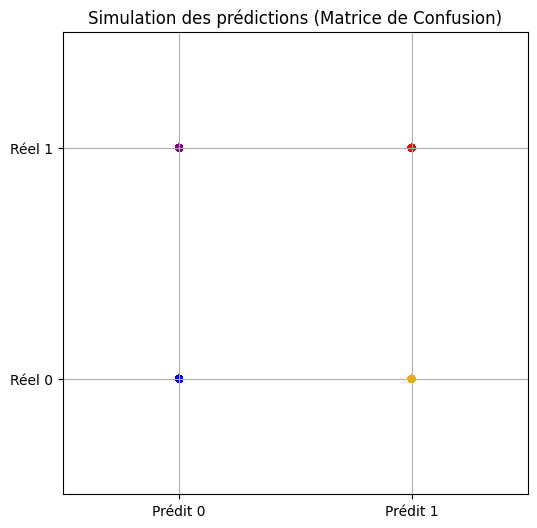

In [27]:
# 🚀 Simulation animée des prédictions pour LinkedIn

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import seaborn as sns

# --- Données de base : matrice de confusion de ton modèle ---
# [[TN, FP],
#  [FN, TP]]
conf_matrix = np.array([[933, 102],
                        [204, 170]])

# Créer des points pour chaque client selon la matrice
points = []
colors = []

# Classe 0 (non-churn)
points += [(0,0)] * conf_matrix[0,0]   # TN
colors += ['blue'] * conf_matrix[0,0]
points += [(1,0)] * conf_matrix[0,1]   # FP
colors += ['orange'] * conf_matrix[0,1]

# Classe 1 (churn)
points += [(0,1)] * conf_matrix[1,0]   # FN
colors += ['purple'] * conf_matrix[1,0]
points += [(1,1)] * conf_matrix[1,1]   # TP
colors += ['red'] * conf_matrix[1,1]

points = np.array(points)

# --- Création de la figure ---
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-0.5,1.5)
ax.set_ylim(-0.5,1.5)
ax.set_xticks([0,1])
ax.set_xticklabels(['Prédit 0', 'Prédit 1'])
ax.set_yticks([0,1])
ax.set_yticklabels(['Réel 0', 'Réel 1'])
ax.set_title("Simulation des prédictions (Matrice de Confusion)")
ax.grid(True)

scat = ax.scatter([], [], s=20)

# --- Fonction d'animation ---
def animate(i):
    scat.set_offsets(points[:i])
    scat.set_color(colors[:i])
    return scat,

# --- Animation ---
ani = FuncAnimation(fig, animate, frames=len(points), interval=1, blit=True)

# --- Sauvegarde en GIF ---
ani.save("churn_simulation.gif", writer=PillowWriter(fps=60))

plt.show()

## 2.Logistic Regression

Type : Modèle linéaire
Avantages : simple, rapide, interprétable, donne des probabilités directement.
Quand l’utiliser : quand les relations entre features et target sont plutôt linéaires.

Objectif : prédire la probabilité qu’un client fasse churn (1) ou reste fidèle (0) à partir des features transformées.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix


lr_model = LogisticRegression(random_state =42 , max_iter =100)
lr_model.fit(x_train , y__train)
#Accuracy
acc_1=accuracy_score(y_test,y_pred)
print("Accuracy:",acc_1)

#Classification Report
print("\nClassification Report:\n",classification_report(y_test,y_pred))

# Confusion matrix
cm_1=confusion_matrix(y_test,y_pred)
print("\n Confusion matrix : \n" , cm_1)



Accuracy: 0.7828246983676366

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.45      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409


 Confusion matrix : 
 [[933 102]
 [204 170]]



---

### 1️⃣ Accuracy

$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$
* **TP** = vrais positifs (clients churn correctement prédits) = 170
* **TN** = vrais négatifs (clients non-churn correctement prédits) = 933
* **FP** = faux positifs (prédit churn alors que non-churn) = 102
* **FN** = faux négatifs (prédit non-churn alors que churn) = 204

$
\text{Accuracy} = \frac{170 + 933}{170 + 933 + 102 + 204} \approx 0.78
$

**Signification pratique** : le modèle prédit correctement environ **78% du temps**. Attention : pour des classes déséquilibrées, l’accuracy seule peut être trompeuse.

---

### 2️⃣ Confusion Matrix

$
\text{Confusion Matrix} =
\begin{bmatrix}
TN & FP \
FN & TP
\end{bmatrix}
$
=============
$
\begin{bmatrix}
933 & 102 \
204 & 170
\end{bmatrix}
$

* **TN (933)** : clients non-churn correctement classés
* **FP (102)** : clients non-churn prédits comme churn
* **FN (204)** : clients churn prédits comme non-churn
* **TP (170)** : clients churn correctement classés

**Intérêt** : visualiser **erreurs du modèle** par classe et savoir si le modèle est meilleur pour détecter churn ou non-churn.

---

### 3️⃣ Classification Report

| Métrique                         | Formule mathématique                                                                                        | Signification pratique                                                        |
| -------------------------------- | ----------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| **Precision (pour la classe 1)** | ( \text{Precision} = \frac{TP}{TP + FP} = \frac{170}{170+102} \approx 0.62 )                                | Parmi tous les clients prédits churn, 62% étaient réellement churn.           |
| **Recall / Sensitivity**         | ( \text{Recall} = \frac{TP}{TP + FN} = \frac{170}{170+204} \approx 0.45 )                                   | Parmi tous les clients churn, le modèle en détecte seulement 45%.             |
| **F1-score**                     | ( F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} \approx 0.53 ) | Moyenne harmonique de precision et recall. Mesure l’équilibre entre les deux. |
| **Support**                      | Nombre réel d’observations par classe                                                                       | Ex : 374 clients churn dans le test set.                                      |

**Observation pratique** :

* Le modèle est **meilleur pour prédire les clients non-churn (classe 0)** que churn (classe 1)
* Cela peut poser problème si l’objectif est de **capter tous les clients churn** pour une action commerciale.

---

💡 **Conclusion** :

* Accuracy = 78%, correct mais ne reflète pas bien la performance sur la classe minoritaire (churn).
* Precision vs Recall : ici **recall faible (0.45)** → beaucoup de churn manqués
* F1-score = 0.53 → performance modérée sur churn
* Confusion matrix → permet de visualiser et ajuster le seuil si nécessaire

---



## XGBoost (Extreme Gradient Boosting)
* Type : Boosting d’arbres de décision.
* Avantages : Très performant sur les datasets tabulaires, gère bien les relations non-linéaires et les interactions complexes.
* Quand l’utiliser : Quand tu veux un modèle précis, robuste, souvent meilleur que Random Forest sur des datasets déséquilibrés.
* Particularités : Gère automatiquement les valeurs manquantes, permet le réglage du poids des classes pour le déséquilibre.

In [34]:
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix


xgb_model =XGBClassifier(random_state=42 , use_label_encoder = False, eval_metric ='logloss')
xgb_model.fit(x_train,y_train)

y_pred_xgb =xgb_model.predict(x_test)

print("=== XGBoost ===")
print("Accuracy_xgb: ",accuracy_score(y_test,y_pred_xgb))
print("\n Classification Report : \n", classification_report(y_test,y_pred_xgb))
print("\n Confusion Matrix :", confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy_xgb:  0.7806955287437899

 Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


 Confusion Matrix : [[911 124]
 [185 189]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:25:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



---

### 1️⃣ Accuracy

* `0.7807` → environ **78% de bonnes prédictions**.
* Comparable à Random Forest (`~78%`) et Logistic Regression (`~78%`).

### 2️⃣ Precision / Recall / F1-score

* **Classe 0 (non-churn)**

  * Precision = 0.83 → 83% des clients prédits non-churn sont corrects.
  * Recall = 0.88 → 88% des vrais non-churn ont été correctement détectés.
  * F1-score = 0.85 → bon compromis entre précision et rappel.
* **Classe 1 (churn)**

  * Precision = 0.60 → 60% des clients prédits churn sont réellement churn.
  * Recall = 0.51 → 51% des vrais churn ont été détectés.
  * F1-score = 0.55 → la classe churn est plus difficile à détecter.

⚠️ Comme tu le vois, **le modèle est meilleur pour prédire les clients fidèles que les churners**.

### 3️⃣ Confusion Matrix

```
[[911 124]
 [185 189]]
```

* **TN (True Negative)** = 911 → clients non-churn correctement prédits
* **FP (False Positive)** = 124 → clients non-churn prédits churn par erreur
* **FN (False Negative)** = 185 → clients churn manqués par le modèle
* **TP (True Positive)** = 189 → clients churn correctement prédits

📌 Cela confirme que le modèle détecte mieux les clients fidèles que les churners.

### 4️⃣ Comparaison rapide

| Modèle              | Accuracy | F1-score Classe 1 |
| ------------------- | -------- | ----------------- |
| Logistic Regression | 0.78     | 0.53              |
| Random Forest       | 0.78     | 0.53              |
| **XGBoost**         | 0.78     | 0.55              |

* XGBoost a un **léger avantage pour détecter les churners** (F1-score un peu plus élevé).
* Globalement, tous les modèles sont similaires en accuracy, mais le **focus sur la détection des churners** peut orienter le choix du modèle.


